# Quais fatores mais influenciam o salário de profissionais de dados no Brasil em 2024?

**Trabalho Final - Análise Avançada de Dados**  
**Integrantes:** Arthur de Holanda e Luis Felipe  
**Fonte:** State of Data Brazil 2024-2025, Data Hackers + Bain & Company.

Este notebook responde à pergunta central por meio de uma sequência reproduzível: reconhecimento da base, limpeza documentada, análise univariada, cruzamentos com salário e uma síntese visual. As conclusões tratam associação, não causalidade.

## 1. Carregamento e reconhecimento

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "dados").exists()), Path.cwd())
DATA_DIR = PROJECT_ROOT / "dados"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"

CSV_CANDIDATES = sorted(DATA_DIR.glob("*.csv"))
if not CSV_CANDIDATES:
    raise FileNotFoundError(
        "Baixe o CSV oficial no Kaggle e coloque-o na pasta dados/. "
        "Use o CSV oficial do State of Data Brazil 2024-2025."
    )
CSV_PATH = CSV_CANDIDATES[0]
df_raw = pd.read_csv(CSV_PATH)
print("Arquivo:", CSV_PATH.name)
print("Dimensões:", df_raw.shape)
df_raw.head()

Arquivo: Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv
Dimensões: (5217, 403)


,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia","1.e.3_Sim, devido a minha identidade de gênero","1.e.4_Sim, devido ao fato de ser PCD",1.i.1_uf_onde_mora,1.f.1_Quantidade de oportunidades de emprego/vagas recebidas,1.f.2_Senioridade das vagas recebidas em relação à sua experiência,1.f.3_Aprovação em processos seletivos/entrevistas,1.f.4_Oportunidades de progressão de carreira,1.f.5_Velocidade de progressão de carreira,1.f.6_Nível de cobrança no trabalho/Stress no trabalho,1.f.7_Atenção dada pelas pessoas diante das minhas opiniões e ideias,"1.f.8_Relação com outras pessoas da empresa, em momentos de trabalho","1.f.9_Relação com outras pessoas da empresa, em momentos de integração e outros momentos fora do trabalho",1.i.2_regiao_onde_mora,1.f_aspectos_prejudicados,1.k.1_uf_de_origem,1.k.2_regiao_de_origem,1.g_vive_no_brasil,1.h_pais_onde_mora,1.i_estado_onde_mora,1.j_vive_no_estado_de_formacao,1.k_estado_de_origem,1.l_nivel_de_ensino,1.m_área_de_formação,2.a_situação_de_trabalho,2.b_setor,2.c_numero_de_funcionarios,2.d_atua_como_gestor,2.e_cargo_como_gestor,2.f_cargo_atual,2.g_nivel,2.h_faixa_salarial,2.i_tempo_de_experiencia_em_dados,2.j_tempo_de_experiencia_em_ti,2.k_satisfeito_atualmente,2.l.1_Remuneração/Salário,2.l.2_Benefícios,2.l.3_Propósito do trabalho e da empresa,2.l.4_Flexibilidade de trabalho remoto,2.l.5_Ambiente e clima de trabalho,2.l.6_Oportunidade de aprendizado e trabalhar com referências,2.l.7_Oportunidades de crescimento,2.l.8_Maturidade da empresa em termos de tecnologia e dados,2.l.9_Relação com os gestores e líderes,2.l.10_Reputação que a empresa tem no mercado,2.l.11_Gostaria de trabalhar em outra área,2.l_motivo_insatisfacao,2.m_participou_de_entrevistas_ultimos_6m,2.n_planos_de_mudar_de_emprego_6m,2.o_criterios_para_escolha_de_emprego,2.o.1_Remuneração/Salário,...,7.d.4_Utilizando API's para extrair dados e complementar minhas análises.,"7.d.5_Realizando experimentos e estudos utilizando metodologias estatísticas como teste de hipótese, modelos de regressão etc.","7.d.6_Desenvolvendo/cuidando da manutenção de ETL's utilizando tecnologias como Talend, Pentaho, Airflow, Dataflow etc.","7.d.7_Atuando na modelagem dos dados, com o objetivo de criar conjuntos de dados como Data Warehouses, Data Marts, Datasets etc.",7.d.8_Desenvolvendo/cuidando da manutenção de planilhas para atender as áreas de negócio.,"7.d.9_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises de dados.",7.d.10_Nenhuma das opções listadas refletem meu dia a dia.,8.a_rotina_como_ds,"8.a.1_Estudos Ad-hoc com o objetivo de confirmar hipóteses, realizar modelos preditivos, forecasts, análise de cluster para resolver problemas pontuais e responder perguntas das áreas de negócio.",8.a.2_Sou responsável pela coleta e limpeza dos dados que uso para análise e modelagem.,"8.a.3_Sou responsável por entrar em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.a.4_Desenvolvo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.a.5_Sou responsável por colocar modelos em produção, criar os pipelines de dados, APIs de consumo e monitoramento.","8.a.6_Cuido da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.a.7_Realizo construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc","8.a.8_Utilizo ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.a.9_Crio e dou manutenção em ETLs, DAGs e automações de pipelines de dados.",8.a.10_Crio e gerencio soluções de Feature Store e cultura de MLOps.,"8.a.11_Sou responsável por criar e manter a infra que meus modelos e

In [2]:
reconhecimento = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "percentual_nulos": (df_raw.isna().mean() * 100).round(2),
})
display(reconhecimento.sort_values("percentual_nulos", ascending=False).head(20))
print("Quantidade de colunas:", df_raw.shape[1])

,dtype,nulos,percentual_nulos
1.h_pais_onde_mora,object,5078,97.34
5.b_oportunidade_buscada,object,4931,94.52
5.d_experiencia_em_processos_seletivos,object,4928,94.46
5.c_tempo_em_busca_de_oportunidade,object,4927,94.44
5.a_objetivo_na_area_de_dados,object,4676,89.63
6.g_ferramentas_de_qualidade_de_dados_(dia_a_dia),object,4657,89.27
6.f_tecnologia_data_warehouse,object,4491,86.08
6.d_tecnologia_data_lake,object,4482,85.91
"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",float64,4444,85.18
8.c_tecnologias_ds,object,4444,85.18


Quantidade de colunas: 403


### Renomeação das colunas-chave

A base oficial usa códigos e descrições extensas. Renomeamos 17 colunas relevantes com nomes curtos e legíveis. O dicionário abaixo deixa explícita a correspondência com a base original e supera o mínimo solicitado de 10 colunas-chave.

In [3]:
RENAME_MAP = {'1.a_idade': 'idade', '1.a.1_faixa_idade': 'faixa_idade', '1.b_genero': 'genero', '1.c_cor/raca/etnia': 'raca_cor', '1.i.2_regiao_onde_mora': 'regiao', '1.l_nivel_de_ensino': 'escolaridade', '2.a_situação_de_trabalho': 'situacao_trabalho', '2.f_cargo_atual': 'cargo_original', '2.g_nivel': 'senioridade', '2.h_faixa_salarial': 'faixa_salarial', '2.i_tempo_de_experiencia_em_dados': 'experiencia_dados', '2.j_tempo_de_experiencia_em_ti': 'experiencia_ti', '2.r_modelo_de_trabalho_atual': 'modelo_trabalho', '4.a_funcao_de_atuacao': 'funcao_atuacao', '4.d.1_SQL': 'usa_sql', '4.d.2_R': 'usa_r', '4.d.3_Python': 'usa_python'}

colunas_ausentes = sorted(set(RENAME_MAP) - set(df_raw.columns))
if colunas_ausentes:
    raise KeyError(f"Colunas esperadas não encontradas no CSV: {colunas_ausentes}")


df = df_raw.rename(columns=RENAME_MAP).copy()
pd.DataFrame(RENAME_MAP.items(), columns=['coluna_original', 'nome_utilizado'])

,coluna_original,nome_utilizado
0,1.a_idade,idade
1,1.a.1_faixa_idade,faixa_idade
2,1.b_genero,genero
3,1.c_cor/raca/etnia,raca_cor
4,1.i.2_regiao_onde_mora,regiao
5,1.l_nivel_de_ensino,escolaridade
6,2.a_situação_de_trabalho,situacao_trabalho
7,2.f_cargo_atual,cargo_original
8,2.g_nivel,senioridade
9,2.h_faixa_salarial,faixa_salarial


## 2. Limpeza e decisões documentadas

### Decisão 1: converter faixas salariais em pontos médios

O salário original é uma faixa textual. Para permitir medidas numéricas, usamos o ponto médio de cada intervalo fechado. Para `Menos de R$ 1.000/mês`, adotamos R$ 500. Para a faixa aberta `Acima de R$ 40.001/mês`, adotamos R$ 45.000, preservando a largura aproximada da faixa anterior. Essa aproximação torna a análise possível, mas reduz precisão e limita a interpretação dos maiores salários.

### Decisão 2: preservar não respostas sensíveis

Não imputamos gênero ou raça/cor. Na base, há categorias explícitas como `Prefiro não informar`; elas não devem ser transformadas em outra resposta. Ausências reais também permanecem ausências.

### Decisão 3: padronizar famílias de cargo

Agrupamos cargos próximos por meio de um mapa explícito, mantendo também a coluna original. Isso facilita comparações sem esconder a decisão analítica.

### Decisão 4: criar escalas ordinais transparentes

Experiência e senioridade são categóricas ordenadas. Criamos versões numéricas apenas para calcular correlação de Spearman, adequada a relações monotônicas. Para `Mais de 10 anos`, usamos 12 anos como referência aproximada.

In [4]:
SALARY_MAP = {'Menos de R$ 1.000/mês': 500.0, 'de R$ 1.001/mês a R$ 2.000/mês': 1500.5, 'de R$ 2.001/mês a R$ 3.000/mês': 2500.5, 'de R$ 3.001/mês a R$ 4.000/mês': 3500.5, 'de R$ 4.001/mês a R$ 6.000/mês': 5000.5, 'de R$ 6.001/mês a R$ 8.000/mês': 7000.5, 'de R$ 8.001/mês a R$ 12.000/mês': 10000.5, 'de R$ 12.001/mês a R$ 16.000/mês': 14000.5, 'de R$ 16.001/mês a R$ 20.000/mês': 18000.5, 'de R$ 20.001/mês a R$ 25.000/mês': 22500.5, 'de R$ 25.001/mês a R$ 30.000/mês': 27500.5, 'de R$ 30.001/mês a R$ 40.000/mês': 35000.5, 'Acima de R$ 40.001/mês': 45000.0}

EXPERIENCE_MAP = {'Não tenho experiência na área de dados': 0.0, 'Menos de 1 ano': 0.5, 'de 1 a 2 anos': 1.5, 'de 3 a 4 anos': 3.5, 'de 5 a 6 anos': 5.5, 'de 7 a 10 anos': 8.5, 'Mais de 10 anos': 12.0}

SENIORITY_MAP = {'Júnior': 1.0, 'Pleno': 2.0, 'Sênior': 3.0}

EDUCATION_MAP = {'Não tenho graduação formal': 0.0, 'Estudante de Graduação': 1.0, 'Graduação/Bacharelado': 2.0, 'Pós-graduação': 3.0, 'Mestrado': 4.0, 'Doutorado ou Phd': 5.0}

CARGO_MAP = {'Analista de Dados/Data Analyst': 'Análise de Dados e BI', 'Analista de BI/BI Analyst': 'Análise de Dados e BI', 'Analista de Negócios/Business Analyst': 'Análise de Dados e BI', 'Cientista de Dados/Data Scientist': 'Ciência de Dados e IA', 'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Ciência de Dados e IA', 'Engenheiro de Dados/Data Engineer/Data Architect': 'Engenharia de Dados', 'Arquiteto de Dados/Data Architect': 'Engenharia de Dados', 'Analytics Engineer': 'Engenharia de Dados', 'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Produto e Gestão', 'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Software e Sistemas', 'Professor/Pesquisador': 'Academia e Pesquisa', 'Estatístico': 'Outros cargos', 'Analista de Suporte/Analista Técnico': 'Outros cargos', 'Outras Engenharias (não inclui dev)': 'Outros cargos', 'Outra Opção': 'Outros cargos'}

df["salario_estimado"] = df["faixa_salarial"].map(SALARY_MAP)
df["experiencia_dados_anos"] = df["experiencia_dados"].map(EXPERIENCE_MAP)
df["senioridade_ordem"] = df["senioridade"].map(SENIORITY_MAP)
df["escolaridade_ordem"] = df["escolaridade"].map(EDUCATION_MAP)
df["cargo_padronizado"] = df["cargo_original"].map(CARGO_MAP).fillna("Não informado")

for coluna in ["usa_sql", "usa_python", "usa_r"]:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

coorte = df.dropna(subset=["salario_estimado"]).copy()
print("Respostas totais:", len(df))
print("Respostas com salário analisável:", len(coorte))
print("Percentual aproveitado:", f"{len(coorte) / len(df):.1%}")

Respostas totais: 5217
Respostas com salário analisável: 4863
Percentual aproveitado: 93.2%


In [5]:
colunas_analise = [
    "idade", "genero", "raca_cor", "regiao", "escolaridade", "situacao_trabalho",
    "cargo_original", "cargo_padronizado", "senioridade", "faixa_salarial",
    "salario_estimado", "experiencia_dados", "experiencia_dados_anos",
    "experiencia_ti", "modelo_trabalho", "usa_sql", "usa_python", "usa_r"
]
nulos = coorte[colunas_analise].isna().sum().sort_values(ascending=False)
display(nulos.to_frame("nulos_na_coorte"))

dashboard = coorte[colunas_analise].copy()
DASHBOARD_DIR.mkdir(exist_ok=True)
dashboard.to_csv(DASHBOARD_DIR / "dados_dashboard.csv", index=False, encoding="utf-8-sig")
print("CSV tratado para o dashboard exportado com", dashboard.shape[0], "linhas.")

,nulos_na_coorte
usa_sql,1274
usa_r,1274
usa_python,1274
senioridade,1045
cargo_original,1045
regiao,130
genero,0
idade,0
situacao_trabalho,0
raca_cor,0


CSV tratado para o dashboard exportado com 4863 linhas.


## 3. Análise univariada

As quatro variáveis numéricas abaixo recebem as medidas solicitadas: média, mediana, moda, desvio padrão, variância, amplitude, assimetria e curtose. A distribuição salarial deve ser interpretada com cautela porque deriva dos pontos médios das faixas.

In [6]:
def resumo_numerico(serie):
    serie = serie.dropna()
    return pd.Series({
        "n": serie.size,
        "média": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "desvio padrão": serie.std(),
        "variância": serie.var(),
        "amplitude": serie.max() - serie.min(),
        "assimetria": serie.skew(),
        "curtose": serie.kurt(),
    })

variaveis_numericas = ["salario_estimado", "idade", "experiencia_dados_anos", "senioridade_ordem"]
estatisticas = pd.DataFrame({coluna: resumo_numerico(coorte[coluna]) for coluna in variaveis_numericas}).T
display(estatisticas)

,n,média,mediana,moda,desvio padrão,variância,amplitude,assimetria,curtose
salario_estimado,"4,863.00","12,028.66","10,000.50","10,000.50","8,997.00","80,945,925.92","44,500.00",1.61,2.89
idade,"4,863.00",32.33,31.00,29.00,7.19,51.64,50.00,0.94,1.24
experiencia_dados_anos,"4,863.00",4.65,3.50,3.50,3.58,12.83,12.00,0.82,-0.34
senioridade_ordem,"3,818.00",2.18,2.00,3.00,0.78,0.61,2.00,-0.33,-1.28


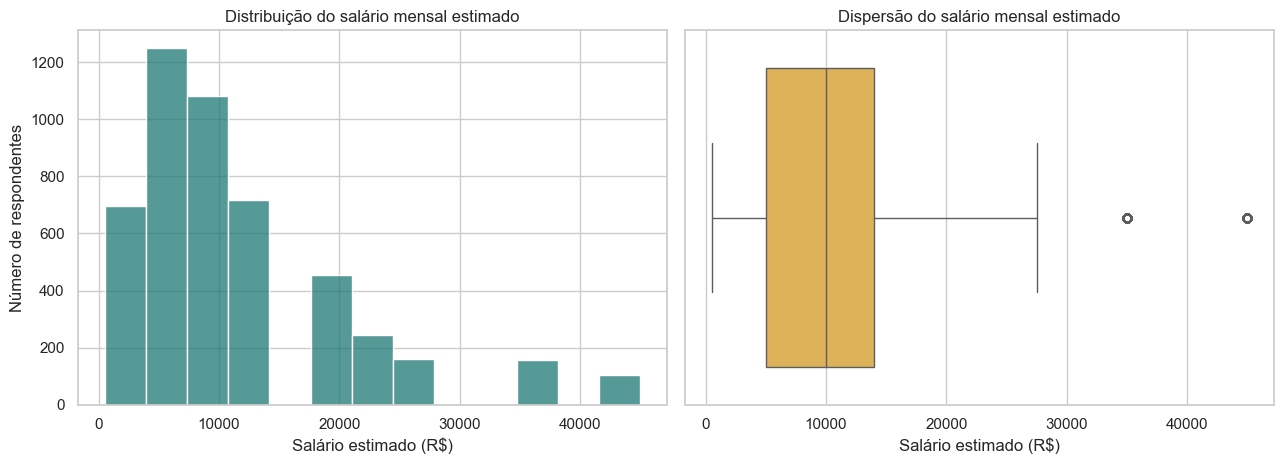

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(coorte["salario_estimado"], bins=13, color="#1D7874", ax=axes[0])
axes[0].set_title("Distribuição do salário mensal estimado")
axes[0].set_xlabel("Salário estimado (R$)")
axes[0].set_ylabel("Número de respondentes")
sns.boxplot(x=coorte["salario_estimado"], color="#F4B942", ax=axes[1])
axes[1].set_title("Dispersão do salário mensal estimado")
axes[1].set_xlabel("Salário estimado (R$)")
plt.tight_layout()
plt.show()

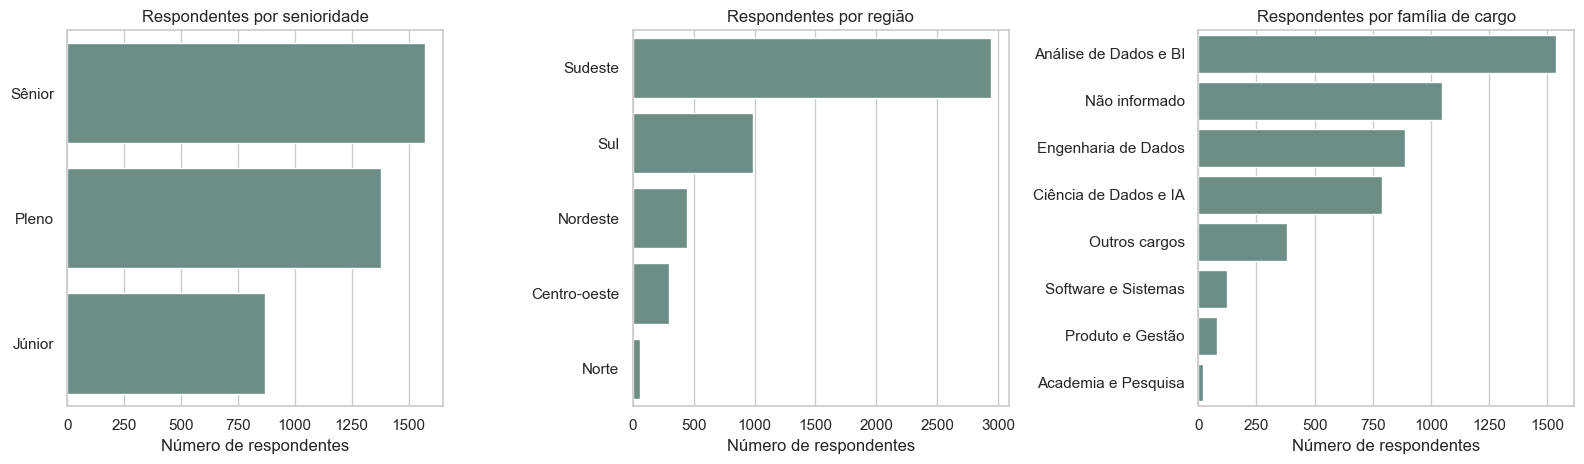

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, coluna, titulo in zip(
    axes,
    ["senioridade", "regiao", "cargo_padronizado"],
    ["Respondentes por senioridade", "Respondentes por região", "Respondentes por família de cargo"],
):
    ordem = coorte[coluna].value_counts().index
    sns.countplot(data=coorte, y=coluna, order=ordem, color="#679289", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("Número de respondentes")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Análise bivariada

O foco é o salário em relação a experiência, senioridade, família de cargo, região e gênero. Para escalas ordinais ou relações monotônicas, usamos Spearman. Diferenças entre grupos são descritivas e não comprovam causalidade.

In [9]:
correlacoes = (
    coorte[["salario_estimado", "idade", "experiencia_dados_anos", "senioridade_ordem", "escolaridade_ordem"]]
    .corr(method="spearman")["salario_estimado"]
    .drop("salario_estimado")
    .sort_values(ascending=False)
)
display(correlacoes.to_frame("correlação de Spearman com salário"))

,correlação de Spearman com salário
senioridade_ordem,0.73
experiencia_dados_anos,0.66
idade,0.44
escolaridade_ordem,0.41


,count,median,mean
senioridade,,,
Júnior,868,"3,500.50","4,157.74"
Pleno,1377,"7,000.50","8,047.70"
Sênior,1573,"14,000.50","14,604.43"


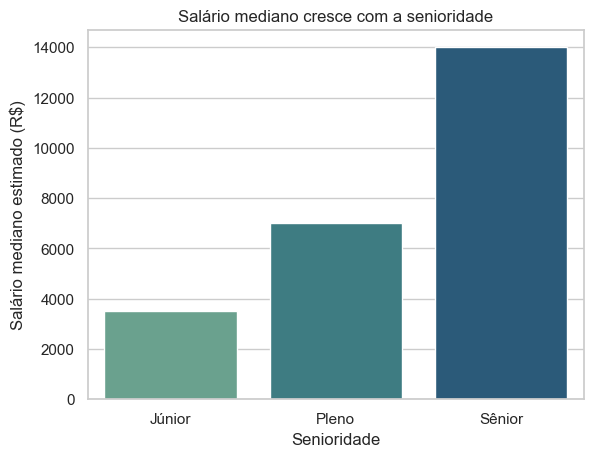

In [10]:
senioridade = coorte.groupby("senioridade", observed=True)["salario_estimado"].agg(["count", "median", "mean"])
display(senioridade.sort_values("median"))

ordem_senioridade = ["Júnior", "Pleno", "Sênior"]
medianas = senioridade["median"].reindex(ordem_senioridade)
ax = sns.barplot(x=medianas.index, y=medianas.values, hue=medianas.index, palette="crest", legend=False)
ax.set_title("Salário mediano cresce com a senioridade")
ax.set_xlabel("Senioridade")
ax.set_ylabel("Salário mediano estimado (R$)")
plt.show()

,count,median,mean
cargo_padronizado,,,
Outros cargos,379,"5,000.50","6,902.85"
Análise de Dados e BI,1537,"7,000.50","7,730.49"
Software e Sistemas,122,"7,000.50","9,275.08"
Ciência de Dados e IA,790,"10,000.50","12,384.04"
Engenharia de Dados,889,"10,000.50","12,524.67"
Produto e Gestão,80,"10,000.50","11,931.75"


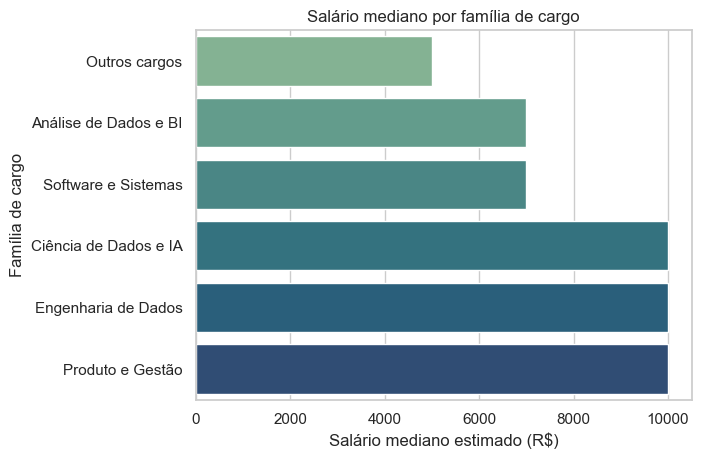

In [11]:
cargo = (
    coorte[coorte["cargo_padronizado"] != "Não informado"]
    .groupby("cargo_padronizado", observed=True)["salario_estimado"]
    .agg(["count", "median", "mean"])
    .query("count >= 30")
    .sort_values("median")
)
display(cargo)
ax = sns.barplot(x=cargo["median"], y=cargo.index, hue=cargo.index, palette="crest", legend=False)
ax.set_title("Salário mediano por família de cargo")
ax.set_xlabel("Salário mediano estimado (R$)")
ax.set_ylabel("Família de cargo")
plt.show()

,count,median,mean
regiao,,,
Centro-oeste,300,"7,000.50","10,165.49"
Nordeste,447,"7,000.50","9,743.21"
Norte,57,"7,000.50","8,711.02"
Sudeste,2940,"10,000.50","12,711.88"
Sul,989,"10,000.50","10,447.41"


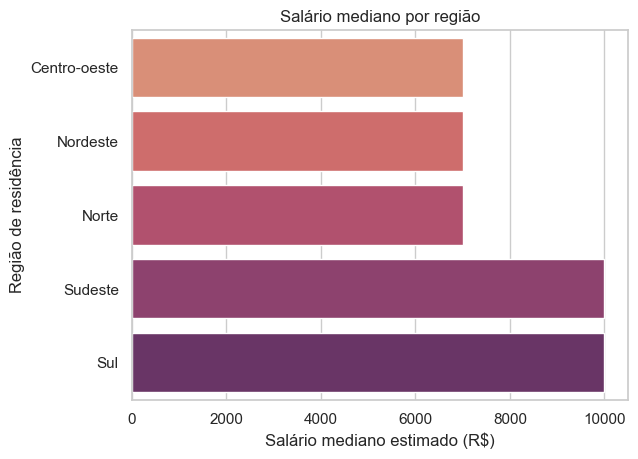

In [12]:
regiao = (
    coorte.groupby("regiao", observed=True)["salario_estimado"]
    .agg(["count", "median", "mean"])
    .query("count >= 30")
    .sort_values("median")
)
display(regiao)
ax = sns.barplot(x=regiao["median"], y=regiao.index, hue=regiao.index, palette="flare", legend=False)
ax.set_title("Salário mediano por região")
ax.set_xlabel("Salário mediano estimado (R$)")
ax.set_ylabel("Região de residência")
plt.show()

### Gênero com controle por senioridade

Comparar apenas a média geral de homens e mulheres pode misturar diferenças de composição entre níveis. Por isso, observamos gênero dentro de cada senioridade. Ainda assim, o resultado não isola todos os fatores relevantes, como cargo, região, experiência e setor.

count    median      mean
senioridade genero                              
Júnior      Feminino     242  3,500.50  4,149.25
            Masculino    623  3,500.50  4,102.41
Pleno       Feminino     366  7,000.50  7,817.44
            Masculino   1006  7,000.50  8,133.70
Sênior      Feminino     335 10,000.50 12,543.78
            Masculino   1229 14,000.50 15,172.58

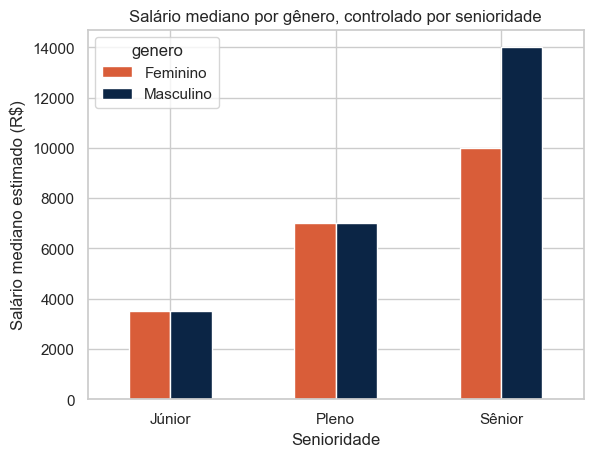

In [13]:
genero_senioridade = (
    coorte[coorte["genero"].isin(["Masculino", "Feminino"])]
    .groupby(["senioridade", "genero"], observed=True)["salario_estimado"]
    .agg(["count", "median", "mean"])
)
display(genero_senioridade)

pivot_genero = genero_senioridade["median"].unstack().reindex(["Júnior", "Pleno", "Sênior"])
pivot_genero.plot(kind="bar", color=["#D95D39", "#0B2545"])
plt.title("Salário mediano por gênero, controlado por senioridade")
plt.xlabel("Senioridade")
plt.ylabel("Salário mediano estimado (R$)")
plt.xticks(rotation=0)
plt.show()

### Ferramentas como variáveis binárias

SQL, Python e R aparecem como colunas 0/1. A frequência é calculada individualmente entre respondentes para os quais o bloco de ferramentas é aplicável. A associação com salário deve ser interpretada com cautela: uma ferramenta pode acompanhar certos cargos ou níveis sem causar remuneração maior.

,percentual_de_uso
SQL,87.70
Python,81.80
R,9.80


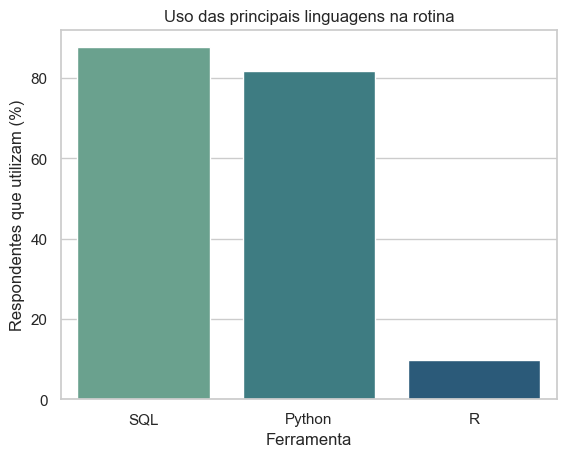

In [14]:
ferramentas = (
    coorte[["usa_sql", "usa_python", "usa_r"]]
    .mean()
    .rename({"usa_sql": "SQL", "usa_python": "Python", "usa_r": "R"})
    .sort_values(ascending=False)
)
display((ferramentas * 100).round(1).to_frame("percentual_de_uso"))
ax = sns.barplot(x=ferramentas.index, y=ferramentas.values * 100, hue=ferramentas.index, palette="crest", legend=False)
ax.set_title("Uso das principais linguagens na rotina")
ax.set_xlabel("Ferramenta")
ax.set_ylabel("Respondentes que utilizam (%)")
plt.show()

## 5. Síntese visual

O gráfico-síntese cruza família de cargo e senioridade. Ele responde diretamente à pergunta central: os salários mais altos se concentram em níveis mais seniores e variam entre famílias de atuação. A experiência acumulada aparece como fator relacionado, enquanto região e diferenças demográficas exigem leitura contextualizada.

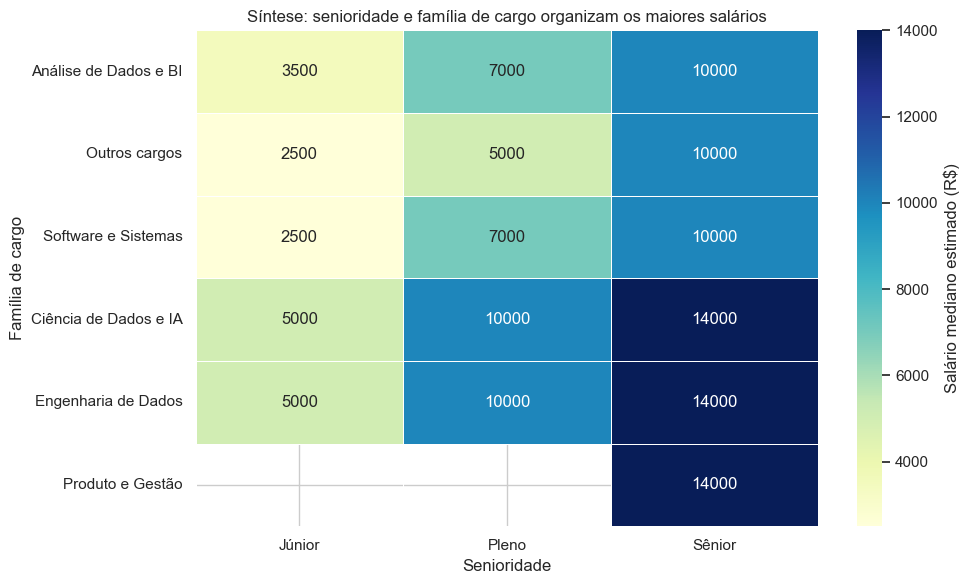

In [15]:
sintese = (
    coorte[coorte["cargo_padronizado"] != "Não informado"]
    .groupby(["cargo_padronizado", "senioridade"], observed=True)["salario_estimado"]
    .agg(["median", "count"])
    .reset_index()
    .query("count >= 20")
)
pivot = sintese.pivot(index="cargo_padronizado", columns="senioridade", values="median")
pivot = pivot.reindex(columns=["Júnior", "Pleno", "Sênior"]).sort_values("Sênior", na_position="last")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, cbar_kws={"label": "Salário mediano estimado (R$)"})
plt.title("Síntese: senioridade e família de cargo organizam os maiores salários")
plt.xlabel("Senioridade")
plt.ylabel("Família de cargo")
plt.tight_layout()
plt.show()

## Conclusão

Os dados indicam que **senioridade e experiência acumulada na área** são os fatores mais diretamente associados ao salário. A **família de cargo** também importa: funções de maior especialização ou responsabilidade apresentam medianas diferentes, mesmo quando o mercado de dados é observado como um conjunto.

Região, gênero, raça/cor, escolaridade e ferramentas ajudam a qualificar a leitura, mas não devem ser comunicados como causas isoladas. A pesquisa é observacional, baseada em respostas voluntárias e usa faixas salariais convertidas em estimativas. Portanto, a conclusão adequada é sobre associação e contexto, não sobre determinação causal.